In [1]:
%reset -f

import networkx as nx
import asymmetree.treeevolve as te
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random

from asymmetree.visualization.tree_vis import visualize, assign_colors
from asymmetree.analysis import orthology_from_tree, bmg_from_tree
from tralda.datastructures.tree import TreeNode
from insertHybrid import insertHybrid
from networkx.drawing.nx_pydot import graphviz_layout
from insertHybrid import convert_to_nx
from insertHybrid import color_leaves

In [2]:
# Zufälligen Genbaum von Assymetree erstellen lassen.
# generate Species Tree

S = te.species_tree_n(n = 3)

# generate Gene Tree

dated_gene_tree = te.dated_gene_tree(
    S,
    dupl_rate=0.5,
    loss_rate=0.1,
    hgt_rate=0,
    dupl_polytomy=0.5
)

full_gene_tree = te.rate_heterogeneity(
    dated_gene_tree,
    S,
    base_rate=0.5,
    autocorr_variance=0.2,
)

# prune all loss branches and the planted root
pruned_gene_tree = te.prune_losses(full_gene_tree)

species_colors, gene_colors = assign_colors(S, dated_gene_tree)

# print(gene_colors)

# visualize(S, color_dict=species_colors)

# visualize(dated_gene_tree, color_dict=gene_colors)
# visualize(full_gene_tree, color_dict=gene_colors)
# visualize(pruned_gene_tree, color_dict=gene_colors)

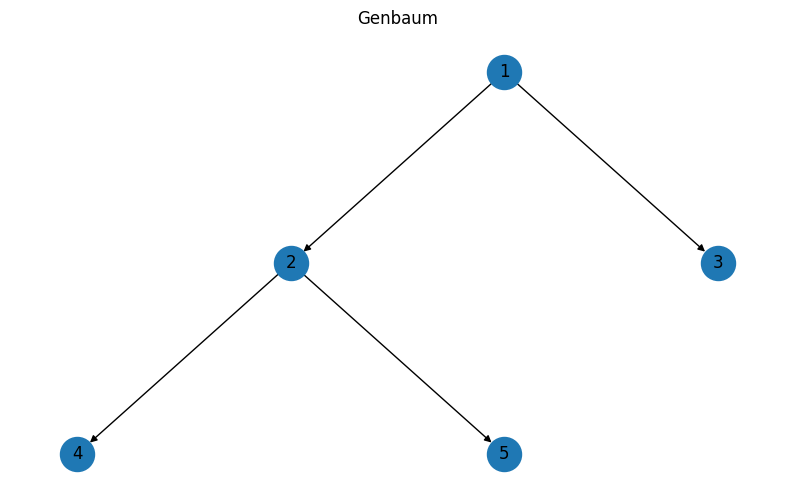

[(1, {'label': 1, 'event': 'S', 'reconc': 1, 'tstamp': 0.23633712189651446, 'transferred': 0, 'dist': 0.0}), (2, {'label': 2, 'event': 'S', 'reconc': 3, 'tstamp': 0.00643611997387139, 'transferred': 0, 'dist': np.float64(0.09972854443592624), 'sibling_nr': 0}), (4, {'label': 4, 'event': 'S', 'reconc': 4, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.0028351886599257783), 'sibling_nr': 0}), (5, {'label': 5, 'event': 'S', 'reconc': 5, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.0027504363542519773), 'sibling_nr': 1}), (3, {'label': 3, 'event': 'S', 'reconc': 2, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.09925446189561468), 'sibling_nr': 1})]


In [3]:
N = convert_to_nx(pruned_gene_tree)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = graphviz_layout(N, prog="dot")

fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()

print(N.nodes(data = True))

Es wurde ein Hybrid zwischen node 1 und node 3 eingefügt und dieser wurde mit Node 4 verbunden
Es wurde ein Hybrid zwischen node 1 und node 2 eingefügt und dieser wurde mit Node 3 verbunden
Es wurde ein Hybrid zwischen node 2 und node 5 eingefügt und dieser wurde mit Node 3 verbunden


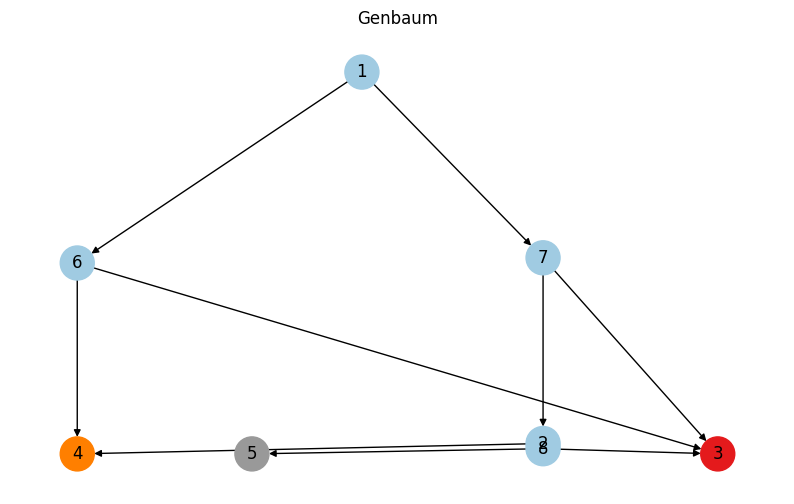

In [4]:
N = insertHybrid(N,3)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = graphviz_layout(N, prog="dot")

# 2. Die Y-Koordinate JEDER Node manipulieren
for node in N.nodes:
    # Wir holen uns das aktuelle [x, y] von Graphviz
    x, y = pos[node]

    # Wir überschreiben y mit dem Timestamp aus den Attributen
    # Da deine Blätter tstamp=0.0 haben und die Root z.B. 0.4,
    # wandern die Blätter automatisch nach unten und die Root nach oben.
    new_y = N.nodes[node]["tstamp"]

    pos[node] = (x, new_y)

node_colors = color_leaves(N)
# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        node_color=node_colors,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()

# for node in G.nodes(data=True):
#     print(node)